In [12]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassConfusionMatrix
)

import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


In [2]:
customcnn_transforms = transforms.Compose([
    transforms.ToTensor()
])

customcnn_test_dataset = ImageFolder(
    "../data/test",
    transform=customcnn_transforms
)

In [3]:
resnet_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet_test_dataset = ImageFolder(
    "../data/test",
    transform=resnet_transforms
)

In [4]:
custom_test_dataloader = DataLoader(
    customcnn_test_dataset,
    batch_size=64,
    shuffle=False
)

resnet_test_dataloader = DataLoader(
    resnet_test_dataset,
    batch_size=64,
    shuffle=False
)

In [5]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layer = nn.Sequential(
            # 3x64x64 -> 32x64x64
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),

            # 32x64x64 -> 64x64x64
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),

            # 64x64x64 -> 128x64x64
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            # 128x64x64 -> 128x32x32
            nn.MaxPool2d(kernel_size=2),

            # 128x32x32 -> 128x32x32
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(),
            # 128x32x32 -> 128x16x16
            nn.MaxPool2d(kernel_size=2),

            # 128x16x16 -> 256x16x16
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            # 256x16x16 -> 256x8x8
            nn.MaxPool2d(kernel_size=2),

            # 256x8x8 -> 256x8x8
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(),
            # 256x8x8 -> 256x4x4
            nn.MaxPool2d(kernel_size=2)
        )

        self.mlp = nn.Sequential(
            # 256x4x4 -> 4096
            nn.Flatten(),

            # 4096 -> 1024
            nn.Linear(in_features=256*4*4, out_features=1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # 1024 -> 256
            nn.Linear(in_features=1024, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # 256 -> 10
            nn.Linear(in_features=256, out_features=10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.mlp(x)

        return x

custom_model = CustomCNN()

custom_model.load_state_dict(
    torch.load("../models/CustomCNNModel.pt")
)

custom_model = custom_model.to(device)

In [6]:
frozen_resnet = models.resnet18(weights=None)
frozen_resnet.fc = nn.Linear(frozen_resnet.fc.in_features, out_features=10)

frozen_resnet.load_state_dict(
    torch.load("../models/TL_Frozen_Backbone.pt")
)

frozen_resnet = frozen_resnet.to(device)

In [7]:
finetuned_resnet = models.resnet18(weights=None)
finetuned_resnet.fc = nn.Linear(finetuned_resnet.fc.in_features, out_features=10)

finetuned_resnet.load_state_dict(
    torch.load("../models/TL_FineTune_Backbone.pt")
)

finetuned_resnet = finetuned_resnet.to(device)

In [8]:
def evaluate_model(model, dataloader, device):

    accuracy = MulticlassAccuracy(num_classes=10).to(device)
    precision = MulticlassPrecision(num_classes=10, average="macro").to(device)
    recall = MulticlassRecall(num_classes=10, average="macro").to(device)

    model.eval()
    with torch.inference_mode():

        for images, labels in dataloader:

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            accuracy.update(outputs, labels)
            precision.update(outputs, labels)
            recall.update(outputs, labels)

    results = {
        "accuracy": accuracy.compute().item(),
        "precision": precision.compute().item(),
        "recall": recall.compute().item()
    }

    return results

In [9]:
custom_results = evaluate_model(custom_model, custom_test_dataloader, device)
frozen_results = evaluate_model(frozen_resnet, resnet_test_dataloader, device)
finetuned_results = evaluate_model(finetuned_resnet, resnet_test_dataloader, device)

In [10]:
results = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet-18 (Frozen)",
        "ResNet-18 (Fine-tuned)"
    ],
    "Accuracy": [
        custom_results["accuracy"],
        frozen_results["accuracy"],
        finetuned_results["accuracy"]
    ],
    "Precision": [
        custom_results["precision"],
        frozen_results["precision"],
        finetuned_results["precision"]
    ],
    "Recall": [
        custom_results["recall"],
        frozen_results["recall"],
        finetuned_results["recall"]
    ]
})

results["Accuracy"] *= 100
results["Precision"] *= 100
results["Recall"] *= 100

results

,Model,Accuracy,Precision,Recall
0,Custom CNN,96.616668,96.728933,96.616668
1,ResNet-18 (Frozen),93.519998,93.609178,93.519998
2,ResNet-18 (Fine-tuned),96.996665,96.918124,96.996665


In [13]:
class_names = customcnn_test_dataset.classes

def get_confusion_matrix(model, dataloader, device):

    cm = MulticlassConfusionMatrix(num_classes=10).to(device)

    model.eval()
    with torch.inference_mode():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            cm.update(outputs, labels)

    return cm

custom_cm = get_confusion_matrix(custom_model, custom_test_dataloader, device)
frozen_cm = get_confusion_matrix(frozen_resnet, resnet_test_dataloader, device)
finetuned_cm = get_confusion_matrix(finetuned_resnet, resnet_test_dataloader, device)

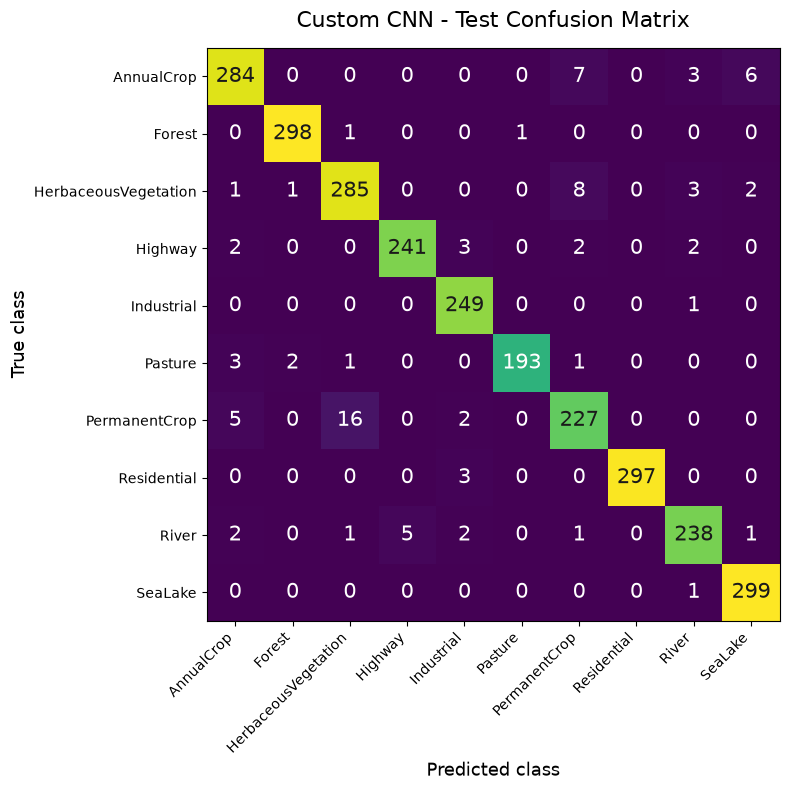

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

custom_cm.plot(labels=class_names, ax=ax)

ax.set_title("Custom CNN - Test Confusion Matrix", fontsize=16, pad=15)
ax.set_xlabel("Predicted class", fontsize=13)
ax.set_ylabel("True class", fontsize=13)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

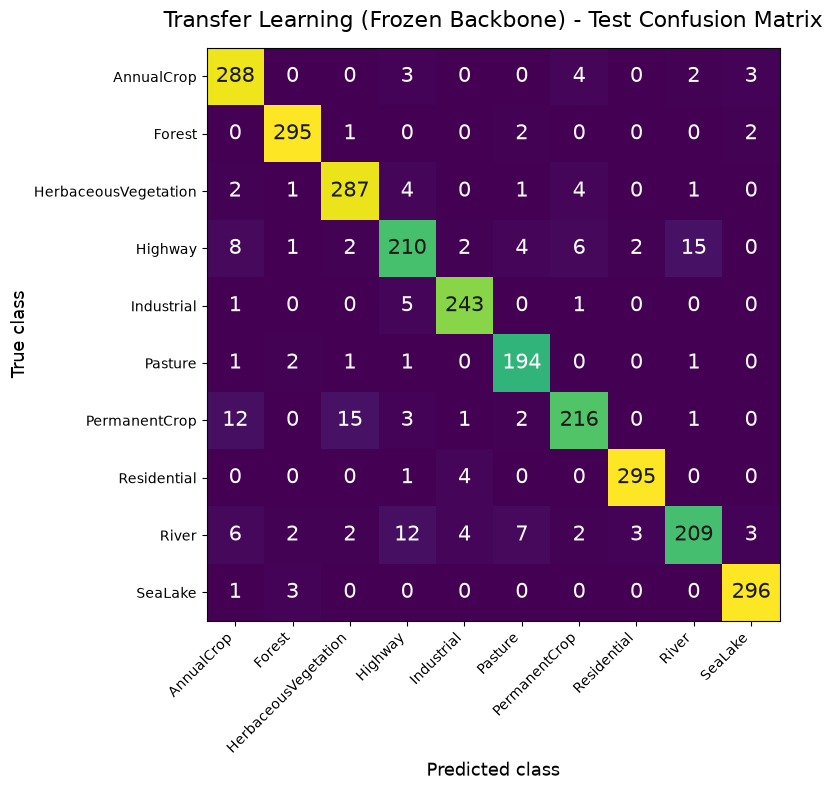

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

frozen_cm.plot(labels=class_names, ax=ax)

ax.set_title("Transfer Learning (Frozen Backbone) - Test Confusion Matrix", fontsize=16, pad=15)
ax.set_xlabel("Predicted class", fontsize=13)
ax.set_ylabel("True class", fontsize=13)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()

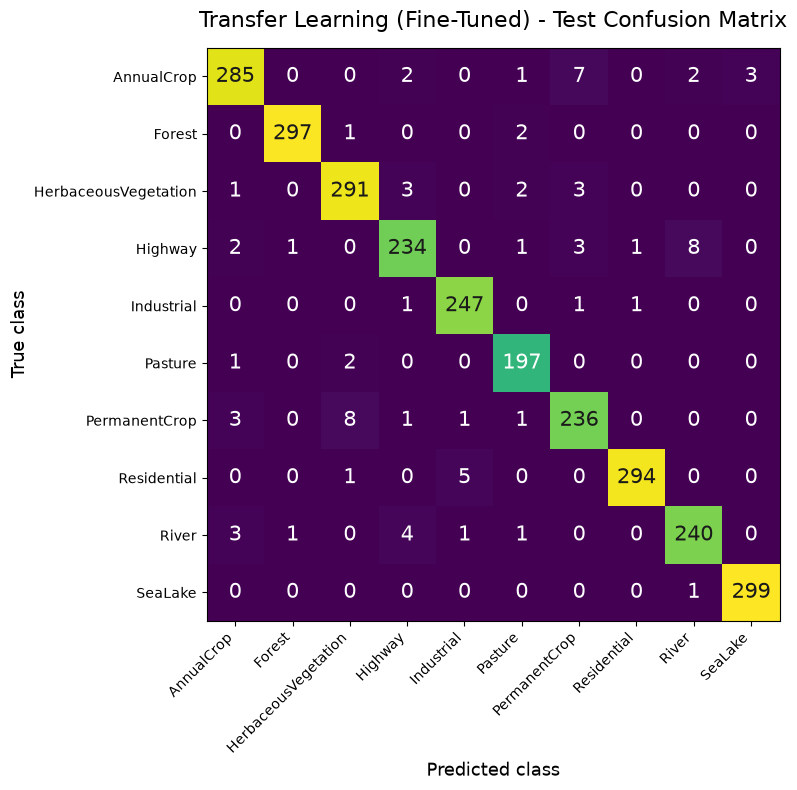

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

finetuned_cm.plot(labels=class_names, ax=ax)

ax.set_title("Transfer Learning (Fine-Tuned) - Test Confusion Matrix", fontsize=16, pad=15)
ax.set_xlabel("Predicted class", fontsize=13)
ax.set_ylabel("True class", fontsize=13)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.setp(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()
plt.show()